In [10]:
import os
import cv2
import numpy as np
from tqdm import tqdm

In [11]:
base_dir = "data/raw/ddd"
output_base = "data/cleaned/ddd"

In [12]:
for label in ["drowsy", "non_drowsy"]:
    os.makedirs(os.path.join(output_base, label), exist_ok=True)

print("Folders created")

Folders created


In [13]:
for label in ["drowsy", "non_drowsy"]:
    path = os.path.join(base_dir, label)
    print(label, "exists:", os.path.exists(path))
    print("Number of files:", len(os.listdir(path)))

drowsy exists: True
Number of files: 22348
non_drowsy exists: True
Number of files: 19445


In [14]:
def mse(img1, img2):
    err = np.sum((img1.astype("float") - img2.astype("float")) ** 2)
    err /= float(img1.shape[0] * img1.shape[1])
    return err

print("MSE ready")

MSE ready


In [15]:
def preprocess(img):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    resized = cv2.resize(gray, (64, 64))
    return resized

print("Preprocess ready")

Preprocess ready


In [16]:
threshold = 10
print("Threshold =", threshold)

Threshold = 10


In [17]:
for label in ["drowsy", "non_drowsy"]:
    
    input_dir = os.path.join(base_dir, label)
    output_dir = os.path.join(output_base, label)

    prev_img = None

    image_files = sorted(os.listdir(input_dir))

    for img_name in tqdm(image_files, desc=label):
        
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        processed = preprocess(img)

        if prev_img is None:
            cv2.imwrite(os.path.join(output_dir, img_name), img)
            prev_img = processed
            continue

        error = mse(prev_img, processed)

        if error > threshold:
            cv2.imwrite(os.path.join(output_dir, img_name), img)
            prev_img = processed

non_drowsy: 100%|██████████| 19445/19445 [01:13<00:00, 266.31it/s]


In [18]:
print("Original drowsy:", len(os.listdir("data/raw/ddd/drowsy")))
print("Cleaned drowsy:", len(os.listdir("data/cleaned/ddd/drowsy")))

print("Original non_drowsy:", len(os.listdir("data/raw/ddd/non_drowsy")))
print("Cleaned non_drowsy:", len(os.listdir("data/cleaned/ddd/non_drowsy")))

Original drowsy: 22348
Cleaned drowsy: 22157
Original non_drowsy: 19445
Cleaned non_drowsy: 19307


###AMBIGUITY REMOVAL###

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [11]:
IMG_SIZE = 128

In [12]:
def process_image(img):
    img_resized = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img_normalized = img_resized / 255.0
    return img_resized, img_normalized

In [13]:
img_path = "data/cleaned/ddd/drowsy/A0003.png"  # change this

img = cv2.imread(img_path)

resized, normalized = process_image(img)

print("Original shape:", img.shape)
print("Resized shape:", resized.shape)
print("Normalized range:", normalized.min(), normalized.max())

Original shape: (227, 227, 3)
Resized shape: (128, 128, 3)
Normalized range: 0.0 1.0


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

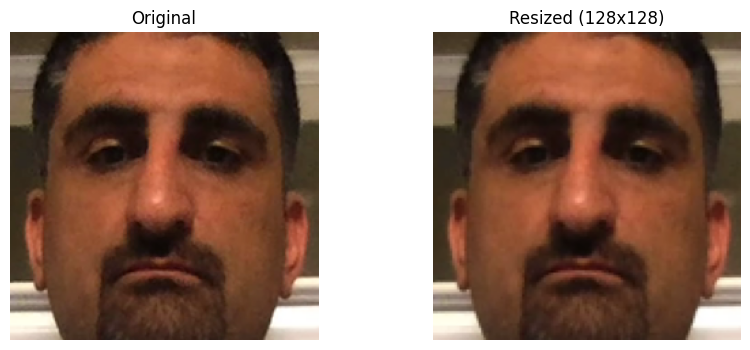

In [14]:
plt.figure(figsize=(10,4))

# Original
plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

# Resized
plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
plt.title("Resized (128x128)")
plt.axis("off")

In [10]:
import os

files = os.listdir("data/cleaned/ddd/drowsy")
print(files[:10])

['H0041.png', 'X0940.png', 'G0527.png', 'E0505.png', 'I0086.png', 'T0465.png', 'S0092.png', 'X0155.png', 'V0566.png', 'I0553.png']


In [15]:
from tqdm import tqdm

input_base = "data/cleaned/ddd"
output_base = "data/final/ddd"

for label in ["drowsy", "non_drowsy"]:
    
    input_dir = os.path.join(input_base, label)
    output_dir = os.path.join(output_base, label)

    os.makedirs(output_dir, exist_ok=True)

    for img_name in tqdm(os.listdir(input_dir), desc=label):
        
        img_path = os.path.join(input_dir, img_name)
        img = cv2.imread(img_path)

        if img is None:
            continue

        resized, normalized = process_image(img)

        # convert back to save
        save_img = (normalized * 255).astype("uint8")

        cv2.imwrite(os.path.join(output_dir, img_name), save_img)

non_drowsy: 100%|██████████| 19307/19307 [00:37<00:00, 509.96it/s]


In [16]:
print("Final drowsy:", len(os.listdir("data/final/ddd/drowsy")))
print("Final non_drowsy:", len(os.listdir("data/final/ddd/non_drowsy")))

Final drowsy: 22157
Final non_drowsy: 19307
